# 01 · Exploración de RelBench — `rel-amazon`
**Temas Avanzados de IA — PUCP 2026**

Cargamos el dataset `rel-amazon` (reseñas de libros de Amazon) y lo exploramos
usando las mismas herramientas de los Labs 8 y 9.

**Estructura del grafo relacional:**
```
customer ──< review >── product
```
Cada `review` conecta un `customer` con un `product`, formando un **grafo bipartito heterogéneo**.

## 0 · Instalación

In [74]:
# Instalar dependencias si es necesario
# !pip install relbench torch-geometric

## 1 · Imports

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import torch

from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
print('Imports OK')

Imports OK


In [76]:
import torch
import torch_geometric
import relbench

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()} | {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"}')
print(f'PyG      : {torch_geometric.__version__}')

PyTorch  : 2.3.0+cu121
CUDA     : True | NVIDIA GeForce RTX 4070 SUPER
PyG      : 2.8.0


## 2 · Utilidades (Labs 8 y 9)

In [77]:
# ─────────────────────────────────────────────────
# Utilidades reutilizadas de Lab 8 y Lab 9
# ─────────────────────────────────────────────────

def visualize(G, h, color, epoch=None, loss=None, title=None):
    """Visualiza el grafo (si h es None) o un scatter de embeddings 2D (si h es tensor)."""
    plt.figure(figsize=(8, 8))
    plt.xticks([])
    plt.yticks([])
    if title:
        plt.title(title, fontsize=14)
    if torch.is_tensor(h):
        h = h.detach().cpu().numpy()
        plt.scatter(h[:, 0], h[:, 1], s=80, c=color, cmap='gist_rainbow')
        if epoch is not None and loss is not None:
            plt.xlabel(f'Epoch: {epoch}, Loss: {loss.item():.4f}', fontsize=14)
    else:
        nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=True,
                         node_color=color, cmap='gist_rainbow')
    plt.tight_layout()
    plt.show()


def graph_information(G):
    """Imprime estadísticas básicas del grafo (Lab 8)."""
    print(f'Número de nodos : {G.number_of_nodes()}')
    print(f'Número de aristas: {G.number_of_edges()}')
    print(f'Es dirigido     : {G.is_directed()}')
    print(f'Es ponderado    : {nx.is_weighted(G)}')


def visualize_graph(G, title='Graph', node_color='skyblue', node_size=300, seed=42):
    """Visualiza un grafo con spring layout (Lab 8)."""
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, with_labels=False, node_color=node_color,
            node_size=node_size, edge_color='gray', alpha=0.8)
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def draw_kkl(nx_G, label_map, node_color, pos=None, title='', **kwargs):
    """Dibuja con spring layout ajustado al tamaño del grafo (Lab 9)."""
    fig, ax = plt.subplots(figsize=(10, 10))
    if pos is None:
        pos = nx.spring_layout(nx_G, k=5 / np.sqrt(nx_G.number_of_nodes()), seed=42)
    nx.draw(nx_G, pos, with_labels=label_map is not None,
            labels=label_map, node_color=node_color, ax=ax, **kwargs)
    if title:
        ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_embeddings_3d(Z, title='3D Embeddings', show_index=False, colors=None):
    """Scatter 3D de una matriz de embeddings Z ∈ R^{n×3} (Lab 8)."""
    if torch.is_tensor(Z):
        Z = Z.detach().cpu().numpy()
    assert Z.shape[1] == 3, 'Se necesitan exactamente 3 dimensiones'
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(projection='3d')
    scatter_kwargs = {'s': 60, 'cmap': 'gist_rainbow'}
    if colors is not None:
        scatter_kwargs['c'] = colors
    ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], **scatter_kwargs)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)
    if show_index:
        for i, (x, y, z) in enumerate(Z):
            ax.text(x, y, z, str(i), fontsize=7)
    plt.tight_layout()
    plt.show()


def compute_mad(Z, mask=None, eps=1e-8):
    """MAD (Mean Average Distance) coseno entre pares de nodos (Lab 8)."""
    if torch.is_tensor(Z):
        Z = Z.detach().cpu().numpy()
    Zn = Z / np.clip(np.linalg.norm(Z, axis=1, keepdims=True), eps, None)
    D = 1.0 - np.clip(Zn @ Zn.T, -1.0, 1.0)
    if mask is None:
        mask = np.ones_like(D)
    else:
        mask = mask.copy()
    np.fill_diagonal(mask, 0)
    total = mask.sum()
    return float((D * mask).sum() / total) if total > 0 else 0.0


def accuracy(pred_y, y):
    """Porcentaje de predicciones correctas."""
    return (pred_y == y).sum() / len(y)


print('Utilidades cargadas ✓')

Utilidades cargadas ✓


## 3 · Cargar `rel-amazon`

In [78]:
from relbench.datasets import get_dataset
from relbench.tasks import get_task

# Primera descarga: ~1.5 GB — puede tardar varios minutos
print('Cargando rel-amazon...')
dataset = get_dataset('rel-amazon', download=True)
db = dataset.get_db()

print(f'\n✓ Dataset cargado')
print(f'  Tablas          : {list(db.table_dict.keys())}')
print(f'  Val timestamp   : {dataset.val_timestamp}')
print(f'  Test timestamp  : {dataset.test_timestamp}')

Cargando rel-amazon...

✓ Dataset cargado
  Tablas          : ['customer', 'product', 'review']
  Val timestamp   : 2015-10-01 00:00:00
  Test timestamp  : 2016-01-01 00:00:00


## 4 · Exploración de tablas

In [79]:
# Resumen de cada tabla
print('=' * 60)
for name, table in db.table_dict.items():
    df = table.df
    print(f'\n Tabla: {name}')
    print(f'   Filas   : {len(df):,}')
    print(f'   Columnas: {list(df.columns)}')
    print(f'   Primary key : {table.pkey_col}')
    print(f'   Foreign keys: {table.fkey_col_to_pkey_table}')
    if table.time_col:
        print(f'   Time col    : {table.time_col}')
print('=' * 60)


 Tabla: customer
   Filas   : 1,850,193
   Columnas: ['customer_id', 'customer_name']
   Primary key : customer_id
   Foreign keys: {}

 Tabla: product
   Filas   : 506,012
   Columnas: ['product_id', 'category', 'brand', 'title', 'description', 'price', 'price_norm']
   Primary key : product_id
   Foreign keys: {}

 Tabla: review
   Filas   : 12,644,508
   Columnas: ['review_time', 'customer_id', 'product_id', 'rating', 'verified', 'review_text', 'summary']
   Primary key : None
   Foreign keys: {'customer_id': 'customer', 'product_id': 'product'}
   Time col    : review_time


In [80]:
# Tabla: customer
df_customer = db.table_dict['customer'].df
print(f'Customers: {len(df_customer):,}')
df_customer.head(5)

Customers: 1,850,193


,customer_id,customer_name
0,0,TW Ervin II
1,1,Amazon Customer
2,2,Tekla Borner
3,3,Deborah K Woroniecki
4,4,E


In [81]:
# Tabla: review (las aristas del grafo bipartito)
df_review = db.table_dict['review'].df
print(f'Reviews: {len(df_review):,}')
df_review.head(5)

Reviews: 12,644,508


,review_time,customer_id,product_id,rating,verified,review_text,summary
2,2015-07-09,3,14,5.0,False,LOVE IT,Five Stars
3,2015-01-18,4,14,5.0,True,Great!,Five Stars
4,2013-11-03,5,14,5.0,False,Over and over the king has problems. Fortunat...,Not Nice Mice
5,2013-10-08,6,14,5.0,True,I remember reading my parents' copy of this bo...,One of my favorite kids' stories
6,2013-01-12,7,14,5.0,True,I am very happy with the book!!! It is one of...,One of our families favorite books!!!


### Nota sobre memoria RAM

La tabla  tiene **12.6 M de filas** (~6 GB en RAM). Cargarla completa para exploración
no tiene mucho sentido: la mayoría de insights estadísticos se pueden ver igual con una muestra.

Por eso usamos **10 % aleatorio (~1.26 M reviews)** para toda la parte visual y de métricas.
Los tensores de PyTorch y las tareas de RelBench (sección 11-12) sí pueden usar el dataset completo
cuando tengamos el pipeline de entrenamiento listo — ahí sí vale la pena.

> Si tienen ≥ 32 GB de RAM pueden poner  sin problema.

In [82]:
# ── Muestra para exploración (reduce RAM de ~6 GB a ~600 MB) ─────────────
SAMPLE_FRAC = 0.10  # 10 % del dataset completo — cambiar a 1.0 si tienen ≥ 32 GB RAM

df_review_full = df_review                                    # referencia al df completo
df_review = df_review.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)

print(f'Muestra activa : {len(df_review):>10,} reviews ({SAMPLE_FRAC:.0%} del total)')
print(f'Dataset completo: {len(df_review_full):>10,} reviews (disponible en df_review_full)')

Muestra activa :  1,264,451 reviews (10% del total)
Dataset completo: 12,644,508 reviews (disponible en df_review_full)


In [83]:
# Tabla: product
df_product = db.table_dict['product'].df
print(f'Products: {len(df_product):,}')
df_product.head(5)

Products: 506,012


,product_id,category,brand,title,description,price,price_norm
0,0,"[Books, Literature & Fiction, Dramas & Plays]",Visit Amazon's William Shakespeare Page,Love's Labour's Lost: Performed by Derek Jacob...,William Shakespeare is widely regarded as the ...,20.93,0.004022
1,1,"[Books, Children's Books, Literature & Fiction]",Louis (ed) UNTERMEYER,The golden treasury of poetry,Collection of Poetry,23.98,0.004608
2,2,"[Books, Mystery, Thriller & Suspense]",Visit Amazon's Agatha Christie Page,The Blue Geranium (Miss Marple),,8.82,0.001695
3,3,"[Books, Humor & Entertainment]",Visit Amazon's Tom Baker Page,Who on Earth Is Tom Baker?,Tom Baker's autobiography covers his childhood...,159.95,0.030736
4,4,"[Books, Christian Books & Bibles, Bible Study ...",Visit Amazon's Clarence Larkin Page,The Greatest Book on &quot;Dispensational Trut...,The Greatest Book on Dispensational Truth in t...,44.76,0.008601


## 5 · Preprocesamiento de datos

Antes de construir el grafo verificamos calidad de los datos:
valores nulos, duplicados, consistencia de foreign keys y normalización de atributos.
Seguimos el mismo esquema de limpieza que en los Labs anteriores.

In [84]:
# ── 5.1 Valores nulos ──────────────────────────────────────────────────────
print("NULOS POR TABLA\n" + "="*50)
for name, df in [("customer", df_customer), ("review", df_review), ("product", df_product)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    pct   = (nulls / len(df) * 100).round(2)
    print(f"\n{name} ({len(df):,} filas):")
    if len(nulls) == 0:
        print("  Sin valores nulos ✓")
    else:
        for col in nulls.index:
            print(f"  {col:20s}: {nulls[col]:>7,} nulos ({pct[col]:.1f}%)")


NULOS POR TABLA

customer (1,850,193 filas):
  Sin valores nulos ✓

review (1,264,451 filas):
  review_text         :      99 nulos (0.0%)
  summary             :     136 nulos (0.0%)

product (506,012 filas):
  category            :  18,854 nulos (3.7%)


In [85]:
# ── 5.2 Duplicados ─────────────────────────────────────────────────────────
dup_review = df_review.duplicated(subset=["customer_id", "product_id"]).sum()
dup_cust   = df_customer.duplicated(subset=["customer_id"]).sum()
dup_prod   = df_product.duplicated(subset=["product_id"]).sum()

print(f"Duplicados (customer_id, product_id) en review : {dup_review:,}")
print(f"Duplicados customer_id en customer              : {dup_cust:,}")
print(f"Duplicados product_id en product                : {dup_prod:,}")

# Eliminar revisiones duplicadas (mismo usuario-producto, me quedo con la más reciente)
if dup_review > 0:
    df_review = (df_review
        .sort_values("review_time", ascending=False)
        .drop_duplicates(subset=["customer_id", "product_id"])
        .reset_index(drop=True))
    print(f"\nReviews tras deduplicar : {len(df_review):,}")
else:
    print("\nSin duplicados en review ✓")


Duplicados (customer_id, product_id) en review : 1,228
Duplicados customer_id en customer              : 0
Duplicados product_id en product                : 0

Reviews tras deduplicar : 1,263,223


In [86]:
# ── 5.3 Integridad de foreign keys ─────────────────────────────────────────
# Toda review debe tener customer_id y product_id válidos
valid_customers = set(df_customer["customer_id"])
valid_products  = set(df_product["product_id"])

orphan_cust = (~df_review["customer_id"].isin(valid_customers)).sum()
orphan_prod = (~df_review["product_id"].isin(valid_products)).sum()

print(f"Reviews con customer_id inválido : {orphan_cust:,}")
print(f"Reviews con product_id inválido  : {orphan_prod:,}")

if orphan_cust > 0 or orphan_prod > 0:
    df_review = df_review[
        df_review["customer_id"].isin(valid_customers) &
        df_review["product_id"].isin(valid_products)
    ].reset_index(drop=True)
    print(f"Reviews tras filtrar FK : {len(df_review):,}")
else:
    print("Integridad referencial OK ✓")


Reviews con customer_id inválido : 0
Reviews con product_id inválido  : 0
Integridad referencial OK ✓


In [87]:
# ── 5.4 Limpieza de atributos ──────────────────────────────────────────────

# Product: rellenar nulos en description y normalizar precio
df_product["description"] = df_product["description"].fillna("")
df_product["brand"]       = df_product["brand"].fillna("Unknown")

# Precio: imputar con mediana y normalizar a [0, 1]
median_price = df_product["price"].median()
df_product["price"] = df_product["price"].fillna(median_price)
price_min, price_max = df_product["price"].min(), df_product["price"].max()
df_product["price_norm"] = (df_product["price"] - price_min) / (price_max - price_min + 1e-8)

# Review: rating normalizado a [0, 1]
df_review["rating_norm"] = (df_review["rating"] - 1) / 4.0  # escala 1-5 → 0-1

# Customer name: vacíos como "Unknown"
df_customer["customer_name"] = df_customer["customer_name"].fillna("Unknown").replace("", "Unknown")

print("Limpieza completada:")
print(f"  product.price    → imputada con mediana={median_price:.2f}, columna price_norm creada")
print(f"  review.rating    → columna rating_norm creada (escala 0-1)")
print(f"  product.description / brand → nulos rellenados con cadena vacía / Unknown")
print(f"\nNulos restantes:")
for name, df in [("customer", df_customer), ("review", df_review), ("product", df_product)]:
    total = df.isnull().sum().sum()
    print(f"  {name}: {total} nulos")


Limpieza completada:
  product.price    → imputada con mediana=12.99, columna price_norm creada
  review.rating    → columna rating_norm creada (escala 0-1)
  product.description / brand → nulos rellenados con cadena vacía / Unknown

Nulos restantes:
  customer: 0 nulos
  review: 235 nulos
  product: 18854 nulos


In [88]:
# ── 5.5 Resumen del dataset preprocesado ───────────────────────────────────
print("DATASET LISTO PARA CONSTRUCCIÓN DEL GRAFO")
print("="*50)
print(f"Customers : {len(df_customer):>10,}")
print(f"Products  : {len(df_product):>10,}")
print(f"Reviews   : {len(df_review):>10,}  (muestra {SAMPLE_FRAC:.0%})")
print(f"Nuevas columnas: price_norm (product), rating_norm (review)")
print(f"\nPeriodo temporal:")
print(f"  Desde : {df_review['review_time'].min()}")
print(f"  Hasta : {df_review['review_time'].max()}")
print(f"  Val   : {dataset.val_timestamp}")
print(f"  Test  : {dataset.test_timestamp}")


DATASET LISTO PARA CONSTRUCCIÓN DEL GRAFO
Customers :  1,850,193
Products  :    506,012
Reviews   :  1,263,223  (muestra 10%)
Nuevas columnas: price_norm (product), rating_norm (review)

Periodo temporal:
  Desde : 2008-01-01 00:00:00
  Hasta : 2016-01-01 00:00:00
  Val   : 2015-10-01 00:00:00
  Test  : 2016-01-01 00:00:00


## 6 · Estadísticas del grafo global


In [89]:
n_customers = len(df_customer)
n_products  = len(df_product)
n_reviews   = len(df_review)
n_nodes     = n_customers + n_products

# Densidad del grafo bipartito: |E| / (|U| * |V|)
density_bipartite = n_reviews / (n_customers * n_products)

# Grado promedio de customers (cuántos productos han reseñado)
deg_customer = df_review.groupby('customer_id').size()
deg_product  = df_review.groupby('product_id').size()

print('━' * 50)
print(f'  Nodos totales     : {n_nodes:>12,}')
print(f'  └─ Customers      : {n_customers:>12,}')
print(f'  └─ Products       : {n_products:>12,}')
print(f'  Aristas (reviews) : {n_reviews:>12,}')
print(f'  Densidad bipartita: {density_bipartite:.6f}')
print()
print(f'  Grado promedio (customer) : {deg_customer.mean():.2f} reseñas/usuario')
print(f'  Grado mediana  (customer) : {deg_customer.median():.0f}')
print(f'  Grado máximo   (customer) : {deg_customer.max()}')
print()
print(f'  Grado promedio (product)  : {deg_product.mean():.2f} reseñas/producto')
print(f'  Grado mediana  (product)  : {deg_product.median():.0f}')
print(f'  Grado máximo   (product)  : {deg_product.max()}')
print('━' * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Nodos totales     :    2,356,205
  └─ Customers      :    1,850,193
  └─ Products       :      506,012
  Aristas (reviews) :    1,263,223
  Densidad bipartita: 0.000001

  Grado promedio (customer) : 1.88 reseñas/usuario
  Grado mediana  (customer) : 1
  Grado máximo   (customer) : 426

  Grado promedio (product)  : 4.88 reseñas/producto
  Grado mediana  (product)  : 2
  Grado máximo   (product)  : 2111
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


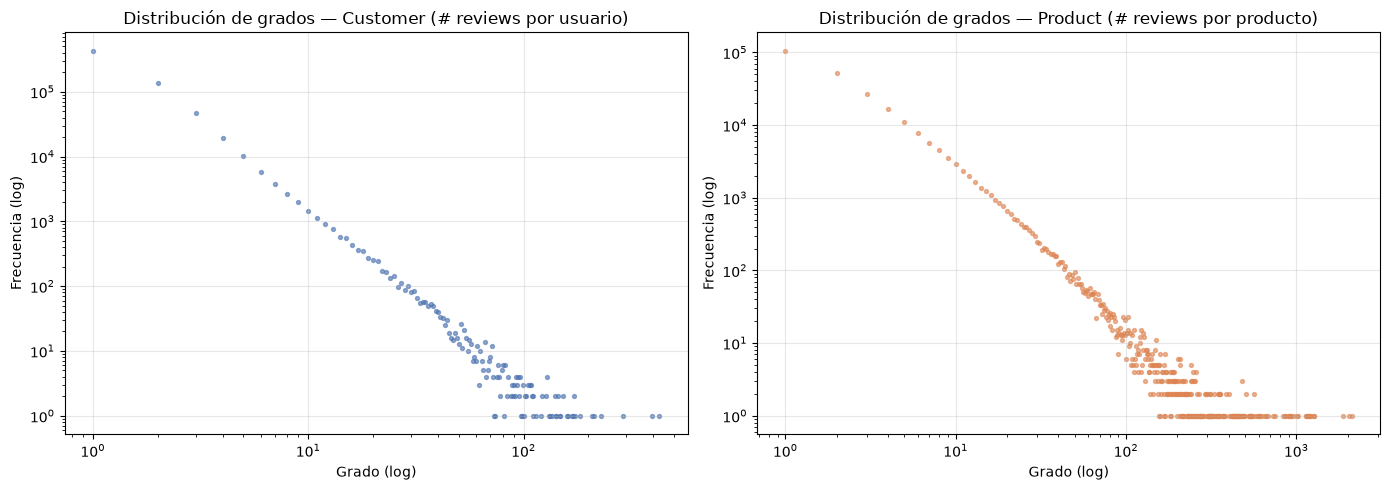

In [90]:
# Distribución de grados — escala log para ver la ley de potencias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (deg, label, color) in zip(axes, [
    (deg_customer, 'Customer (# reviews por usuario)', '#4C72B0'),
    (deg_product,  'Product (# reviews por producto)', '#DD8452'),
]):
    counts = Counter(deg.values)
    x = sorted(counts.keys())
    y = [counts[k] for k in x]
    ax.scatter(x, y, s=8, alpha=0.6, color=color)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Grado (log)')
    ax.set_ylabel('Frecuencia (log)')
    ax.set_title(f'Distribución de grados — {label}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

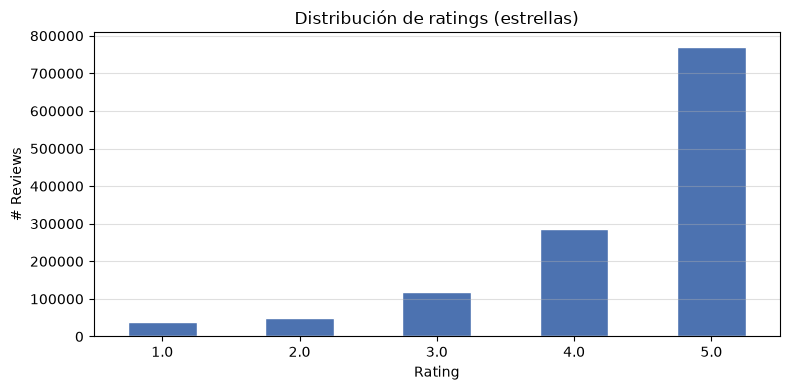

In [91]:
# Rating distribution
if 'rating' in df_review.columns:
    plt.figure(figsize=(8, 4))
    df_review['rating'].value_counts().sort_index().plot(kind='bar', color='#4C72B0', edgecolor='white')
    plt.title('Distribución de ratings (estrellas)')
    plt.xlabel('Rating')
    plt.ylabel('# Reviews')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

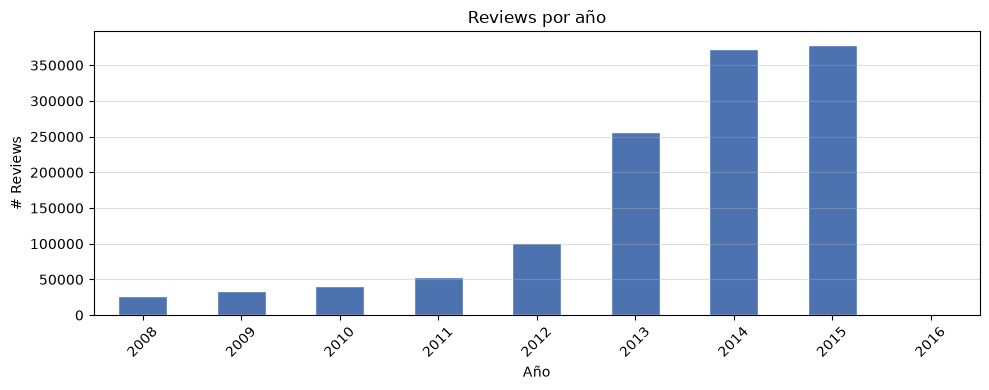

In [92]:
# Reviews por año
time_col = db.table_dict['review'].time_col
if time_col and time_col in df_review.columns:
    df_review['year'] = pd.to_datetime(df_review[time_col]).dt.year
    plt.figure(figsize=(10, 4))
    df_review['year'].value_counts().sort_index().plot(kind='bar', color='#4C72B0', edgecolor='white')
    plt.title('Reviews por año')
    plt.xlabel('Año')
    plt.ylabel('# Reviews')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

## 6 · Construcción del subgrafo (muestra para visualización)

El grafo completo tiene ~15M aristas — no se puede dibujar directamente.  
Tomamos una muestra de los **top-K customers** con más reviews y sus productos.

In [93]:
# Parámetros de la muestra
TOP_CUSTOMERS = 30    # usuarios con más actividad
MAX_REVIEWS   = 5     # máx. reviews por usuario en la muestra

# Seleccionar top customers
top_customers = deg_customer.nlargest(TOP_CUSTOMERS).index.tolist()

# Filtrar reviews de esos customers
df_sub = df_review[df_review['customer_id'].isin(top_customers)].copy()

# Limitar a MAX_REVIEWS por customer (para no saturar el grafo)
df_sub = df_sub.groupby('customer_id').head(MAX_REVIEWS).reset_index(drop=True)

sub_customers = df_sub['customer_id'].unique().tolist()
sub_products  = df_sub['product_id'].unique().tolist()

print(f'Subgrafo: {len(sub_customers)} customers | {len(sub_products)} products | {len(df_sub)} edges')

Subgrafo: 30 customers | 149 products | 150 edges


In [94]:
# Construir grafo NetworkX bipartito
G_sub = nx.Graph()

# Nodos con tipo como atributo
G_sub.add_nodes_from([f'u_{c}' for c in sub_customers], bipartite=0, ntype='customer')
G_sub.add_nodes_from([f'p_{p}' for p in sub_products],  bipartite=1, ntype='product')

# Aristas: customer ── review ── product (weight = rating)
for _, row in df_sub.iterrows():
    u = f'u_{row["customer_id"]}'
    p = f'p_{row["product_id"]}'
    weight = row.get('rating', 1)
    G_sub.add_edge(u, p, weight=weight)

print('Info del subgrafo:')
graph_information(G_sub)

Info del subgrafo:
Número de nodos : 179
Número de aristas: 150
Es dirigido     : False
Es ponderado    : True


## 7 · Visualización del subgrafo

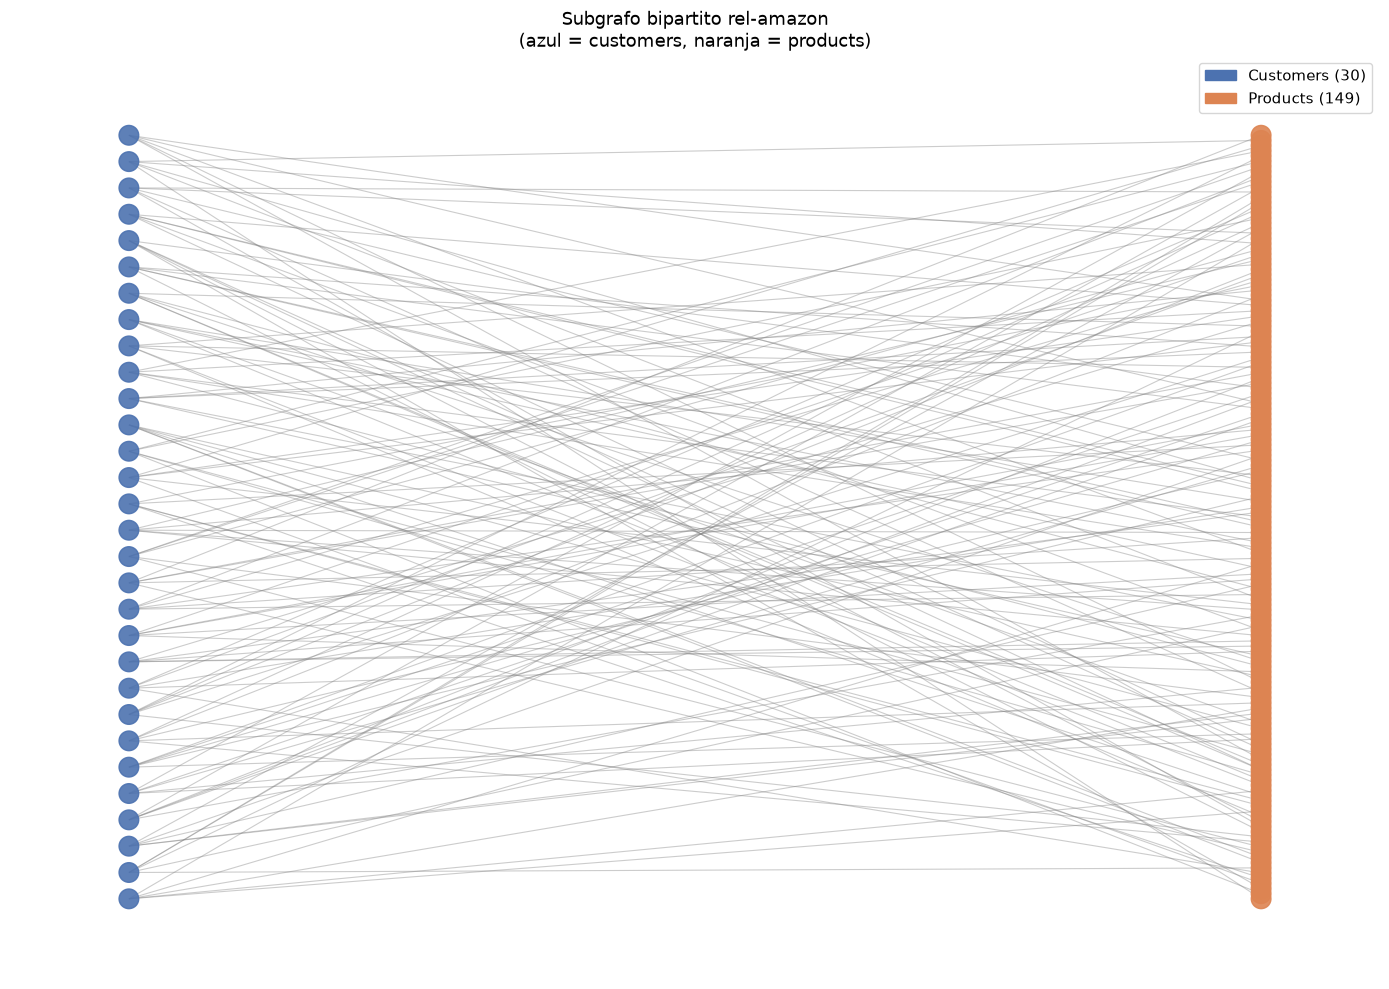

In [95]:
# Colores: azul = customer, naranja = product
node_colors = [
    '#4C72B0' if G_sub.nodes[n]['ntype'] == 'customer' else '#DD8452'
    for n in G_sub.nodes
]

# Layout bipartito
customers_set = {n for n, d in G_sub.nodes(data=True) if d['ntype'] == 'customer'}
pos_bip = nx.bipartite_layout(G_sub, customers_set)

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G_sub, pos_bip, node_color=node_colors, node_size=200, ax=ax, alpha=0.9)
nx.draw_networkx_edges(G_sub, pos_bip, ax=ax, edge_color='gray', alpha=0.4, width=0.8)
ax.set_title(f'Subgrafo bipartito rel-amazon\n(azul = customers, naranja = products)', fontsize=13)
ax.axis('off')

# Leyenda
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#4C72B0', label=f'Customers ({len(sub_customers)})'),
    Patch(color='#DD8452', label=f'Products ({len(sub_products)})'),
], fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

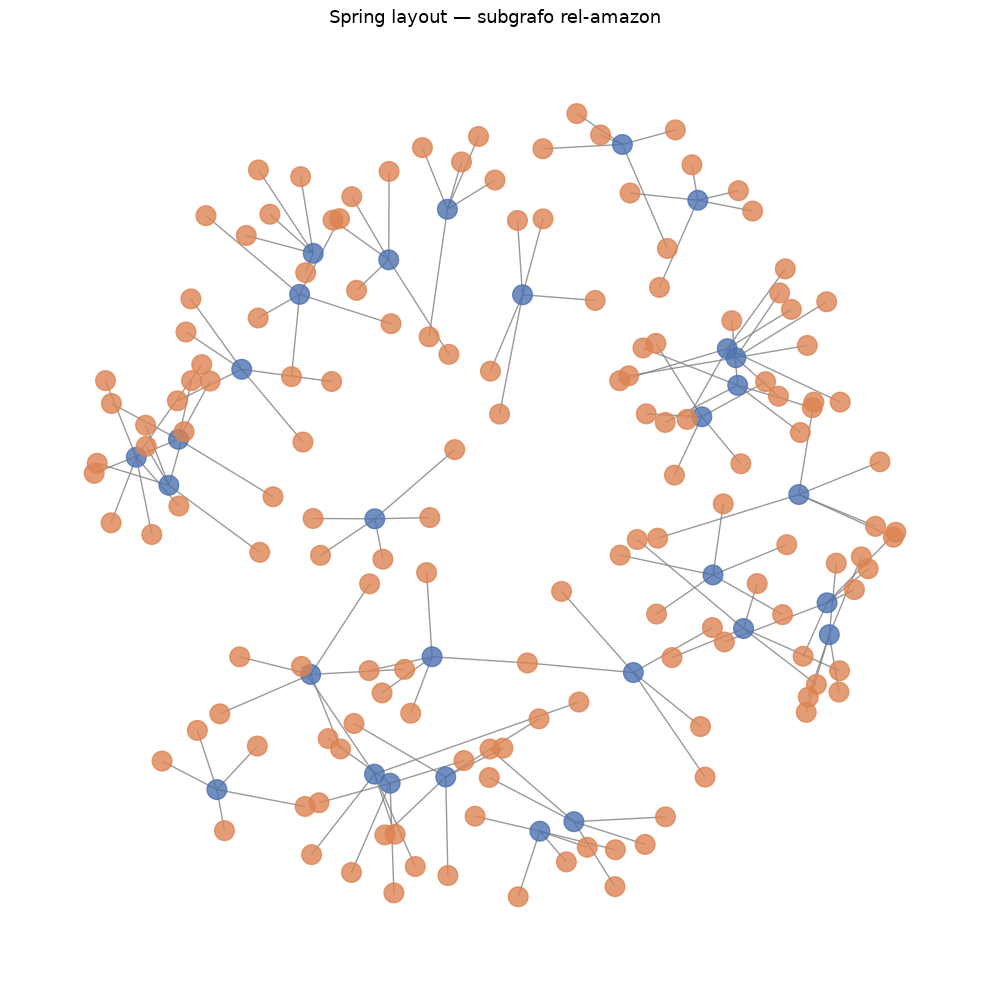

In [96]:
# Visualización con spring layout (función del Lab 9)
draw_kkl(
    G_sub,
    label_map=None,
    node_color=node_colors,
    title='Spring layout — subgrafo rel-amazon',
    edge_color='gray',
    alpha=0.8,
    node_size=200,
)

## 8 · Métricas de densidad del subgrafo

In [97]:
n_sub_customers = len(sub_customers)
n_sub_products  = len(sub_products)
n_sub_edges     = G_sub.number_of_edges()

density_sub = n_sub_edges / (n_sub_customers * n_sub_products)
avg_deg_c   = 2 * n_sub_edges / n_sub_customers
avg_deg_p   = 2 * n_sub_edges / n_sub_products

print('Métricas del subgrafo:')
print(f'  Density (bipartita) : {density_sub:.4f}')
print(f'  Avg degree customer : {avg_deg_c:.2f}')
print(f'  Avg degree product  : {avg_deg_p:.2f}')
print(f'  Clustering coeff    : {nx.average_clustering(G_sub):.4f}')
print()
print('Métricas del grafo GLOBAL:')
print(f'  Density (bipartita) : {density_bipartite:.6f}')
print(f'  Avg degree customer : {deg_customer.mean():.2f}')
print(f'  Avg degree product  : {deg_product.mean():.2f}')

Métricas del subgrafo:
  Density (bipartita) : 0.0336
  Avg degree customer : 10.00
  Avg degree product  : 2.01
  Clustering coeff    : 0.0000

Métricas del grafo GLOBAL:
  Density (bipartita) : 0.000001
  Avg degree customer : 1.88
  Avg degree product  : 4.88


## 9 · Embeddings aleatorios + MAD (Lab 8)

Generamos embeddings aleatorios para los nodos del subgrafo y calculamos MAD.  
Esto sirve como **baseline de referencia** antes de entrenar un GNN.

In [98]:
np.random.seed(42)
n_sub = G_sub.number_of_nodes()
dim   = 3

Z_rand = np.random.randn(n_sub, dim)
Z_rand = Z_rand / np.linalg.norm(Z_rand, axis=1, keepdims=True)

# MAD global
mad_global = compute_mad(Z_rand)

# MAD vecinos vs. remotos usando la matriz de adyacencia del subgrafo
nodes_list = list(G_sub.nodes)
A = nx.to_numpy_array(G_sub, nodelist=nodes_list)
mad_nbrs   = compute_mad(Z_rand, mask=A)
mad_remote = compute_mad(Z_rand, mask=1.0 - A)
mad_gap    = mad_remote - mad_nbrs

print(f'MAD global   = {mad_global:.4f}')
print(f'MAD vecinos  = {mad_nbrs:.4f}')
print(f'MAD remotos  = {mad_remote:.4f}')
print(f'MADGap       = {mad_gap:.4f}  ← esperado ≈ 0 con embeddings aleatorios')

MAD global   = 0.9930
MAD vecinos  = 1.0139
MAD remotos  = 0.9922
MADGap       = -0.0217  ← esperado ≈ 0 con embeddings aleatorios


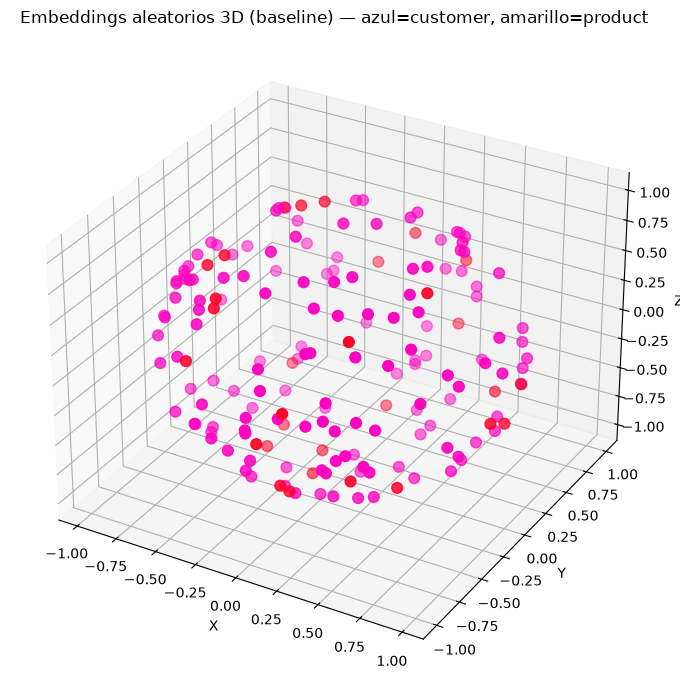

In [99]:
# Colores para la visualización 3D: 0 = customer, 1 = product
colors_3d = np.array([0 if G_sub.nodes[n]['ntype'] == 'customer' else 1 for n in nodes_list])

plot_embeddings_3d(
    Z_rand,
    title='Embeddings aleatorios 3D (baseline) — azul=customer, amarillo=product',
    show_index=False,
    colors=colors_3d
)

## 10 · Construcción del HeteroData para PyG

Convertimos el grafo relacional a `HeteroData` de PyTorch Geometric,
listo para entrenar un GNN heterogéneo.

In [100]:
from torch_geometric.data import HeteroData

# Re-indexar IDs a enteros 0-based
cust_idx = {cid: i for i, cid in enumerate(sub_customers)}
prod_idx = {pid: i for i, pid in enumerate(sub_products)}

src = torch.tensor([cust_idx[r] for r in df_sub['customer_id']], dtype=torch.long)
dst = torch.tensor([prod_idx[r] for r in df_sub['product_id']],  dtype=torch.long)

# Features dummy (identity) — en la práctica vendrían de las tablas
data_pyg = HeteroData()
data_pyg['customer'].x = torch.eye(len(sub_customers))
data_pyg['product'].x  = torch.eye(len(sub_products))
data_pyg['customer', 'reviews', 'product'].edge_index = torch.stack([src, dst])

# Aristas inversas (bidireccionalidad)
data_pyg['product', 'rev_reviews', 'customer'].edge_index = torch.stack([dst, src])

# Rating como atributo de arista
if 'rating' in df_sub.columns:
    ratings = torch.tensor(df_sub['rating'].values, dtype=torch.float).unsqueeze(1)
    data_pyg['customer', 'reviews', 'product'].edge_attr = ratings

print(data_pyg)
print()
print(f'Tipos de nodos : {data_pyg.node_types}')
print(f'Tipos de aristas: {data_pyg.edge_types}')

HeteroData(
  customer={ x=[30, 30] },
  product={ x=[149, 149] },
  (customer, reviews, product)={
    edge_index=[2, 150],
    edge_attr=[150, 1],
  },
  (product, rev_reviews, customer)={ edge_index=[2, 150] }
)

Tipos de nodos : ['customer', 'product']
Tipos de aristas: [('customer', 'reviews', 'product'), ('product', 'rev_reviews', 'customer')]


## 11 · Tareas disponibles en `rel-amazon`

In [101]:
from relbench.tasks import get_task_names

tasks = get_task_names('rel-amazon')
print('Tareas en rel-amazon:')
for t in tasks:
    print(f'  - {t}')

Tareas en rel-amazon:
  - user-churn
  - user-ltv
  - item-churn
  - item-ltv
  - user-item-purchase
  - user-item-rate
  - user-item-review
  - review-rating


In [102]:
# Cargar una tarea de ejemplo: predicción de compras futuras (link prediction)
task = get_task('rel-amazon', 'user-item-purchase', download=True)

train_table = task.get_table('train')
val_table   = task.get_table('val')
test_table  = task.get_table('test')

print('Tarea: user-item-purchase')
print(f'  Train: {len(train_table.df):,} filas')
print(f'  Val  : {len(val_table.df):,} filas')
print(f'  Test : {len(test_table.df):,} filas')
print(f'  Métricas: {task.metrics}')
train_table.df.head()

Tarea: user-item-purchase
  Train: 5,112,803 filas
  Val  : 351,876 filas
  Test : 393,985 filas
  Métricas: [<function link_prediction_precision at 0x0000020EBD128FE0>, <function link_prediction_recall at 0x0000020EBD128F40>, <function link_prediction_map at 0x0000020EBD129080>]


,timestamp,customer_id,product_id
0,2014-04-03,393192,"[80225, 12439]"
1,2014-04-03,149856,"[38972, 29137, 422124, 61124, 80784]"
2,2014-04-03,384140,"[40744, 129519, 410405]"
3,2014-04-03,747159,"[26162, 22215, 26195]"
4,2014-04-03,318496,[12321]


## 12 · Resumen final

| Característica          | Valor |
|-------------------------|-------|
| Tablas                  | customer, review, product |
| Estructura del grafo    | Bipartito heterogéneo |
| Filas totales           | ~15 M |
| Tasks                   | 8 (clasificación, regresión, link prediction) |
| Métricas                | AUROC, MAE, MAP |

**Próximos pasos:**
- `02_baseline_gnn.ipynb` — entrenar un GNN heterogéneo sobre `user-item-purchase`
- `03_node_features.ipynb` — encoding de features textuales con sentence transformers